# Évaluation de la régression logistique

CSI4506 Introduction à l’intelligence artificielle

Marcel Turcotte (École de génie électrique et d’informatique, Université
d’Ottawa)  
2026-09-20

Ce carnet reprend la mise en œuvre de la régression logistique du cours
6 afin de pouvoir être exécuté indépendamment. Il porte principalement
sur l’évaluation des modèles : rapports de classification, matrices de
confusion, courbes ROC, AUC et effet d’un changement du seuil de
classification.

# Mise en œuvre de la régression logistique

La classe ajoute l’ordonnée à l’origine et suit les mêmes équations
d’entropie croisée binaire et de descente de gradient par lot qu’au
cours 6.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml, load_breast_cancer, make_blobs
from sklearn.linear_model import LogisticRegression as SKLogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

class LogisticRegression:

    """
    Régression logistique binaire entraînée par descente de gradient par lot.

    Paramètres
    ----------
    learning_rate : float, default=0.1
        Pas de la descente de gradient.
    max_iter : int, default=1000
        Nombre d'itérations de la descente de gradient.
    Remarques
    -----
    - Cette mise en œuvre attend des étiquettes binaires {0, 1}.
    - L'ordonnée à l'origine est ajoutée pendant `fit`.
    - Par souci de simplicité, il n'y a ni régularisation ni arrêt précoce.
    """

    def __init__(self, learning_rate: float = 0.1, max_iter: int = 1000):
        if learning_rate <= 0:
            raise ValueError("learning_rate doit être positif.")
        if max_iter <= 0:
            raise ValueError("max_iter doit être positif.")

        self.learning_rate = learning_rate
        self.max_iter = max_iter

        # Attributs définis après l'ajustement
        self._theta = None             # forme : (n_features + 1,), ordonnée à l'origine comprise
        self._loss_history = None      # liste de nombres à virgule flottante
        self._n_features = None        # nombre d'attributs vus pendant fit (sans l'ordonnée à l'origine)
        self._fitted = False

    # ---------- Interface publique ----------

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LogisticRegression":
        """
        Ajuster les paramètres du modèle par descente de gradient.

        Paramètres
        ----------
        X : array-like, shape (n_samples, n_features)
            Matrice d'attributs (SANS colonne d'ordonnée à l'origine; elle sera ajoutée).
        y : array-like, shape (n_samples,)
            Étiquettes binaires cibles dans {0, 1}.

        Retourne
        -------
        self : LogisticRegression
        """
        X = self._as_2d_array(X, name="X")
        y = self._as_1d_array(y, name="y")

        if X.shape[0] != y.shape[0]:
            raise ValueError("X et y doivent contenir le même nombre d'exemples.")
        self._check_binary_labels(y)

        m, n = X.shape
        self._n_features = n

        # Ajouter une colonne de uns pour l'ordonnée à l'origine
        Xb = self._add_intercept(X)

        # Une initialisation à zéro suffit puisque l'objectif est convexe.
        self._theta = np.zeros(n + 1, dtype=float)

        self._loss_history = []

        # Descente de gradient
        for _ in range(self.max_iter):
            z = Xb @ self._theta
            h = self._sigmoid(z)                       # probabilités prédites
            grad = (Xb.T @ (h - y)) / m                # gradient de l'entropie croisée binaire
            self._theta -= self.learning_rate * grad   # mise à jour
            updated_h = self._sigmoid(Xb @ self._theta)
            self._loss_history.append(self._bce_loss(updated_h, y))

        self._fitted = True
        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """
        Retourner les probabilités prédites de la classe positive.

        Soulève
        ------
        RuntimeError : si la méthode est appelée avant fit
        ValueError : si X n'a pas le même nombre d'attributs que pendant fit
        """
        self._ensure_fitted()
        X = self._as_2d_array(X, name="X")
        self._ensure_same_n_features(X)

        Xb = self._add_intercept(X)
        return self._sigmoid(Xb @ self._theta)

    def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        """
        Retourner les classes prédites (0/1) selon un seuil de probabilité.

        Soulève
        ------
        RuntimeError : si la méthode est appelée avant fit
        ValueError : si X n'a pas le même nombre d'attributs que pendant fit
        """
        if not 0 <= threshold <= 1:
            raise ValueError("threshold doit être compris entre 0 et 1.")
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)

    @property
    def intercept_(self) -> float:
        """Retourner l'ordonnée à l'origine ajustée."""
        self._ensure_fitted()
        return float(self._theta[0])

    @property
    def coef_(self) -> np.ndarray:
        """Retourner une copie des coefficients ajustés des attributs."""
        self._ensure_fitted()
        return self._theta[1:].copy()

    def get_loss_history(self) -> list:
        """
        Retourner une copie des pertes (entropie croisée binaire) de l'ajustement.

        Soulève
        ------
        RuntimeError : si la méthode est appelée avant fit
        """
        self._ensure_fitted()
        return list(self._loss_history)

    # ---------- Méthodes auxiliaires ----------

    @staticmethod
    def _sigmoid(z: np.ndarray) -> np.ndarray:
        """Calculer la sigmoïde sans débordement pour les grandes valeurs négatives."""
        z = np.asarray(z, dtype=float)
        result = np.empty_like(z)
        positive = z >= 0
        result[positive] = 1.0 / (1.0 + np.exp(-z[positive]))
        exp_z = np.exp(z[~positive])
        result[~positive] = exp_z / (1.0 + exp_z)
        return result

    @staticmethod
    def _bce_loss(h: np.ndarray, y: np.ndarray) -> float:
        h_clipped = np.clip(h, 1e-12, 1.0 - 1e-12)
        return float(-np.mean(y * np.log(h_clipped) + (1 - y) * np.log(1 - h_clipped)))

    @staticmethod
    def _as_2d_array(X, name="X") -> np.ndarray:
        X = np.asarray(X, dtype=float)
        if X.ndim != 2:
            raise ValueError(f"{name} doit être un tableau 2D de forme (n_samples, n_features).")
        return X

    @staticmethod
    def _as_1d_array(y, name="y") -> np.ndarray:
        y = np.asarray(y, dtype=float)
        if y.ndim != 1:
            raise ValueError(f"{name} doit être un tableau 1D de forme (n_samples,).")
        return y

    @staticmethod
    def _check_binary_labels(y: np.ndarray) -> None:
        if not np.array_equal(np.unique(y), np.array([0.0, 1.0])):
            raise ValueError("y doit contenir les deux étiquettes binaires 0 et 1.")

    def _add_intercept(self, X: np.ndarray) -> np.ndarray:
        return np.column_stack([np.ones(X.shape[0]), X])

    def _ensure_fitted(self) -> None:
        if not self._fitted or self._theta is None:
            raise RuntimeError("Cette instance de LogisticRegression n'est pas encore ajustée. Appelez d'abord `fit(X, y)`.")

    def _ensure_same_n_features(self, X: np.ndarray) -> None:
        if X.shape[1] != self._n_features:
            raise ValueError(
                f"Nombre d'attributs incompatible : X en contient {X.shape[1]}, mais le modèle a été ajusté avec {self._n_features}."
            )

# Exemple d’évaluation synthétique

Nous commençons par un jeu de données à deux attributs afin d’évaluer
les probabilités prédites sans introduire un domaine d’application
complexe.

In [2]:
X, y = make_blobs(n_samples=1000, n_features=2, centers=2, cluster_std=2.5, random_state=42)

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## Entraînement et prédictions à seuil fixe

In [3]:
model = LogisticRegression(learning_rate=0.1, max_iter=500)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Rapport de classification :\n")
print(classification_report(y_test, y_pred))

Rapport de classification :

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       150
           1       0.98      0.97      0.98       150

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300


# Mise en œuvre de ROC et de l’AUC

In [4]:
def compute_roc_curve(y_true, y_scores):
    """Calculer les points ROC en faisant varier le seuil de classification."""
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores, dtype=float)
    thresholds = np.r_[np.inf, np.sort(np.unique(y_scores))[::-1], -np.inf]

    tpr_list, fpr_list = [], []
    for threshold in thresholds:
        # Classer comme positif si la probabilité prédite est supérieure ou égale au seuil
        y_pred = (y_scores >= threshold).astype(int)
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        tn = np.sum((y_true == 0) & (y_pred == 0))

        tpr_list.append(tp / (tp + fn))
        fpr_list.append(fp / (fp + tn))

    return np.array(fpr_list), np.array(tpr_list), thresholds

## Calcul de l’AUC

In [5]:
def compute_auc(fpr, tpr):
    """
    Calculer l'aire sous la courbe (AUC) par la règle des trapèzes.
    
    fpr : tableau des taux de faux positifs
    tpr : tableau des taux de vrais positifs
    """
    return np.trapezoid(tpr, fpr)

## Courbe ROC

AUC calculée manuellement : 0.999
AUC de scikit-learn :      0.999

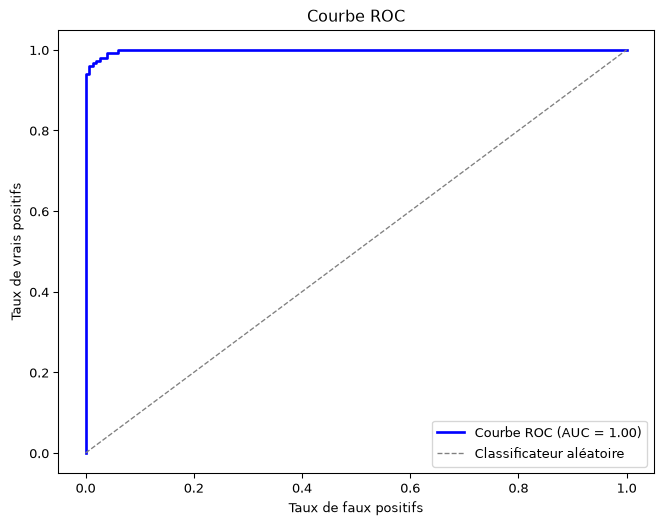

In [6]:
# Calculer les probabilités prédites de la classe positive sur l'ensemble de test
y_probs = model.predict_proba(X_test)

# Calculer la courbe ROC (FPR et TPR pour chaque seuil)
fpr, tpr, thresholds = compute_roc_curve(y_test, y_probs)
auc_value = compute_auc(fpr, tpr)
sklearn_auc = roc_auc_score(y_test, y_probs)

print(f"AUC calculée manuellement : {auc_value:.3f}")
print(f"AUC de scikit-learn :      {sklearn_auc:.3f}")

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='Courbe ROC (AUC = %0.2f)' % auc_value)
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Classificateur aléatoire')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC')
plt.legend(loc="lower right")
plt.show()

# Jeu de données sur le cancer du sein

Cet exemple utilise le jeu de données sur le cancer du sein de
scikit-learn. Dans ce jeu de données, l’étiquette 0 désigne une tumeur
maligne et l’étiquette 1, une tumeur bénigne.

Forme du jeu de données : (569, 30), étiquettes : [212 357]
Noms des attributs (les 5 premiers) : ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']

Rapport de classification :
              precision    recall  f1-score   support

     maligne       0.98      0.98      0.98        42
     bénigne       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


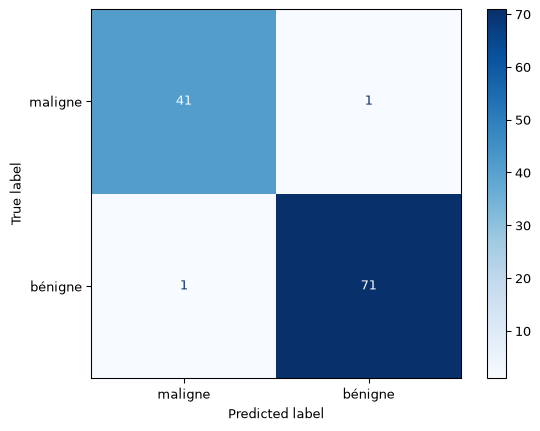

In [7]:
# Objectif : classer les tumeurs comme malignes (0) ou bénignes (1)
# Jeu de données : sklearn.datasets.load_breast_cancer
# Modèle : régression logistique (scikit-learn)

# 1. Charger le jeu de données
data = load_breast_cancer()
X, y = data.data, data.target
target_names_fr = np.array(["maligne", "bénigne"])
print(f"Forme du jeu de données : {X.shape}, étiquettes : {np.bincount(y)}")
print("Noms des attributs (les 5 premiers) :", data.feature_names[:5])

# 2. Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Mettre les attributs à l'échelle (important pour les méthodes à base de gradient)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Entraîner la régression logistique
clf = SKLogisticRegression(max_iter=5000, random_state=42)
clf.fit(X_train_scaled, y_train)

# 5. Évaluer
y_pred = clf.predict(X_test_scaled)

print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=target_names_fr, zero_division=0))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names_fr)
disp.plot(cmap="Blues")
plt.show()

# Jeu de données sur le diabète chez les Pimas

Ce jeu de données illustre comment le seuil de classification détermine
le compromis entre le taux de vrais positifs et le taux de faux
positifs. Les taux indiqués sont calculés à partir de la division
actuelle en ensembles d’entraînement et de test plutôt que fixés dans le
texte.

Forme du jeu de données : (768, 8), étiquettes : [500 268]

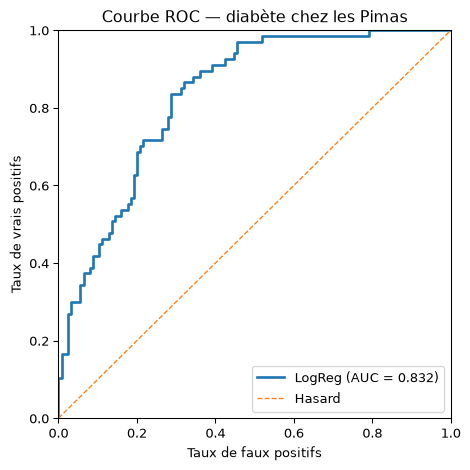

TPR le plus proche : 0.851
FPR correspondant :  0.312
Seuil :              0.271

In [8]:
# 1) Charger le jeu de données Pima au moyen de son identifiant OpenML stable.
dataset = fetch_openml(data_id=37, as_frame=True)
X = dataset.data
y = dataset.target.astype(str).str.lower().map(
    {
        "tested_negative": 0,
        "tested_positive": 1,
        "0": 0,
        "1": 1,
    }
)

if y.isna().any():
    raise ValueError("Les étiquettes cibles d'OpenML n'ont pas été reconnues.")

y = y.astype(int)
print(f"Forme du jeu de données : {X.shape}, étiquettes : {np.bincount(y)}")

# 2) Diviser en ensembles d'entraînement et de test (stratification des classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 3) Mettre les attributs à l'échelle (facilite l'optimisation)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# 4) Entraîner la régression logistique
clf = SKLogisticRegression(max_iter=2000, random_state=42)
clf.fit(X_train_s, y_train)

# 5) Courbe ROC et AUC
y_score = clf.predict_proba(X_test_s)[:, 1]     # probabilité de la classe positive
fpr, tpr, thresholds = roc_curve(y_test, y_score)
auc = roc_auc_score(y_test, y_score)

# 6) Tracer la courbe
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, lw=2, label=f"LogReg (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], lw=1, linestyle="--", label="Hasard")
plt.xlim(0, 1); plt.ylim(0, 1)
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC — diabète chez les Pimas")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Indiquer le point de fonctionnement le plus proche du TPR cible.
target_tpr = 0.85
idx = np.argmin(np.abs(tpr - target_tpr))

print(f"TPR le plus proche : {tpr[idx]:.3f}")
print(f"FPR correspondant :  {fpr[idx]:.3f}")
print(f"Seuil :              {thresholds[idx]:.3f}")